In [1]:
import GWDALI as gw
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Setting GW source parameters

In [2]:
GwPrms = {}
GwPrms['dL']       = 1.55 # Gpc
GwPrms['Mc']       = 36.0 # Solar Mass
GwPrms['eta']      = 0.24
GwPrms['iota']     = np.pi/4 # radians
GwPrms['t_coal']   = 0.1    # seconds
GwPrms['phi_coal'] = np.pi/4 # radians

GwPrms["sx1"]  = 0.
GwPrms["sy1"]  = 0.
GwPrms["sz1"]  = 0.1

GwPrms["sx2"]  = 0.
GwPrms["sy2"]  = 0.
GwPrms["sz2"]  = -0.3

## Computing GW polarizations with JAX and LAL waveforms

In [3]:
approx = "IMRPhenomD"

dF = 0.01          # sampling rate used in lalsumulation
disable_jit = True # enable/disable Just-In-Time compilation (jax.jit())

freq = np.arange(10,1.e3,dF) # frequency

# enable_jax_waveforms: 
#   False -> waveforms from lalsimulation
#   True  -> waveforms from GWDALI (JAX friendly) 

hp_lal, hx_lal = gw.get_hphx(GwPrms,freq,approx,enable_jax_waveforms=False,dF=dF)
hp_jax, hx_jax = gw.get_hphx(GwPrms,freq,approx,enable_jax_waveforms=True,disable_jit=disable_jit)

>> Disabling jax.jit()


In [4]:
# Auxiliar function for plotting

Amplitude = lambda x: np.real( np.sqrt(x*np.conj(x)) )
Phase = lambda x: np.unwrap(np.angle(x))/np.pi

### Computing Strains from GW polarizations

$$h\equiv h_+-i\ h_{\times}$$

NameError: name 'fmax' is not defined

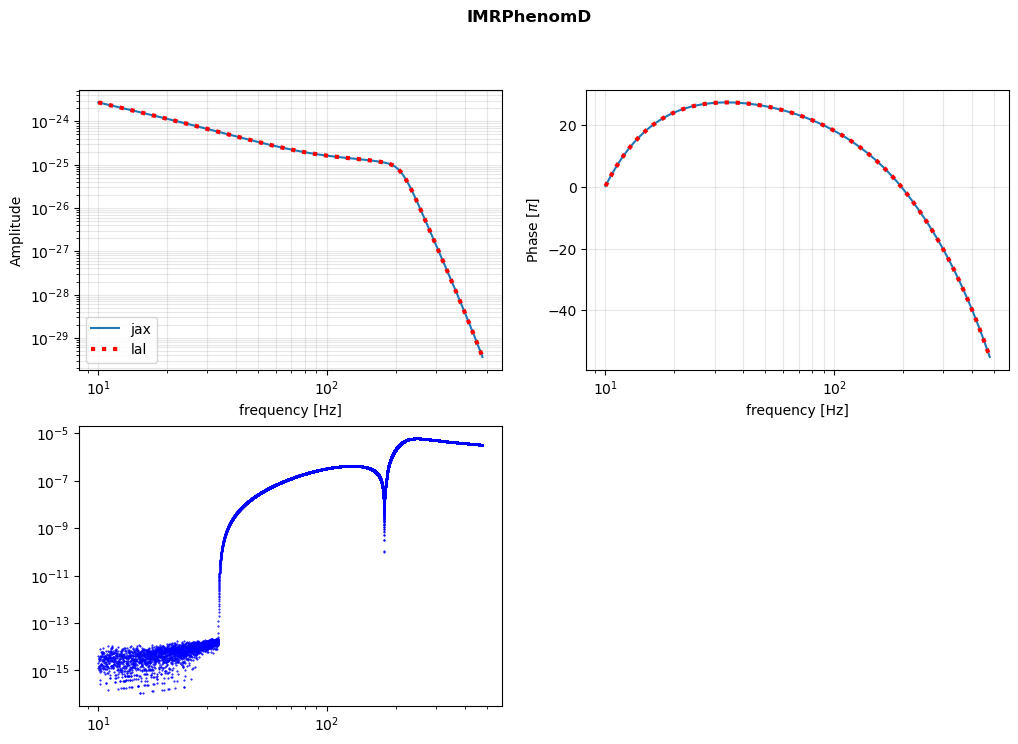

In [5]:
h_jax = hp_jax - 1.j*hx_jax
h_lal = hp_lal - 1.j*hx_lal

Amp = np.array( [ Amplitude(h) for h in [h_jax, h_lal]]) 
Phi = np.array( [ Phase(h) for h in [h_jax, h_lal]]) 

idxs = np.where(Amp[1]>0)[0][:-1]
Amp = [ a[idxs] for a in Amp ]
Phi = [ p[idxs] for p in Phi ]
f = freq[idxs]

fig = plt.figure(figsize=(12,8))
plt.suptitle(approx,weight='bold')
plt.subplot(221)
plt.loglog(f,Amp[0],label='jax')
plt.loglog(f,Amp[1],'r:',lw=3,label='lal')
plt.ylabel("Amplitude")
plt.xlabel('frequency [Hz]')
plt.legend(loc='lower left')
plt.grid(which='both',alpha=.3)

plt.subplot(222)
plt.plot(f,Phi[0])
plt.plot(f,Phi[1],'r:',lw=3)
plt.ylabel("Phase [$\\pi$]")
plt.xlabel('frequency [Hz]')
plt.grid(which='both',alpha=.3)
plt.xscale('log')

diffA = np.abs( Amp[0] - Amp[1] ) / Amp[1]
diffP = np.abs( Phi[0] - Phi[1] )

plt.subplot(223)
plt.loglog(f,diffA,'b.',ms=1)
plt.xlim(freq[0],fmax)
plt.grid(which='both',alpha=.3)
plt.xlabel('frequency [Hz]')
plt.ylabel("Relative Diff. Amplitude")

plt.subplot(224)
plt.loglog(f,diffP,'b.',ms=1)
plt.grid(which='both',alpha=.3)
plt.xlabel('frequency [Hz]')
plt.ylabel("$\\Delta$ Phase [$\\pi$]")

plt.tight_layout()